# Unobserved Confounding Example

obs_df: DataFrame with columns 'treatment_obs' (T_i) and 'y_obs' (Y_i)
Model: Y_i = θ · T_i + z_i + ε_i where:
  - T_i ∈ {0, 1}
  - z_i ~ N(0, σ²) unobserved
 - Y_i observed with p(1/(1+e^(-z_i)))
  - ε_i ~ N(0, 0.5²)


In [1]:
import os

import bayesflow as bf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from tqdm import tqdm
from cmdstanpy import CmdStanModel
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.trainers import Trainer
from scipy.special import logit, expit

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [37]:
# Parameters
np.random.seed(42)
n_population = 1000  # Full population size
n_samples = 20
#observed_covariates = np.exp(np.random.normal(size=n_population))
param_names = ['treatment_effect', 'health_awareness']

def selection_probability(z):
    """Calculate selection probability p(1/(1+e^(-z)))"""
    return 1 / (1 + np.exp(-z))

def clinical_trial_model(treatment_effect: float = 1.7, health_awareness: float = 1.):
    # Generate true population data
    z = health_awareness * np.random.normal(0, 1, n_population)
    treatment = np.random.binomial(1, 0.5, n_population)
    epsilon = np.random.normal(0, 0.5, n_population)
    y = treatment_effect * treatment + z + epsilon
    prob_obs = selection_probability(z)
    selected = np.random.binomial(1, prob_obs)
    # Observed data
    y_obs = y[selected == 1]
    treatment_obs = treatment[selected == 1]
    selected_index = np.random.choice(np.arange(len(y_obs)), n_samples, replace=False)
    
    # Create the observed sample data
    observed_data = pd.DataFrame({
        'treatment_obs': treatment_obs[selected_index],
        'y_obs': y_obs[selected_index],
        #'observed_covariates': observed_covariates[selected == 1][selected_index],
        'unobserved_confounder': z[selected == 1][selected_index]
    })
    
    # Full population data (for reference)
    population_data = pd.DataFrame({
        'treatment_obs': treatment,
        'y_obs': y,
        #'observed_covariates': observed_covariates,
        'unobserved_confounder': z
    })
    return observed_data, population_data

obs, pop = clinical_trial_model()
print(obs.shape)

(20, 3)


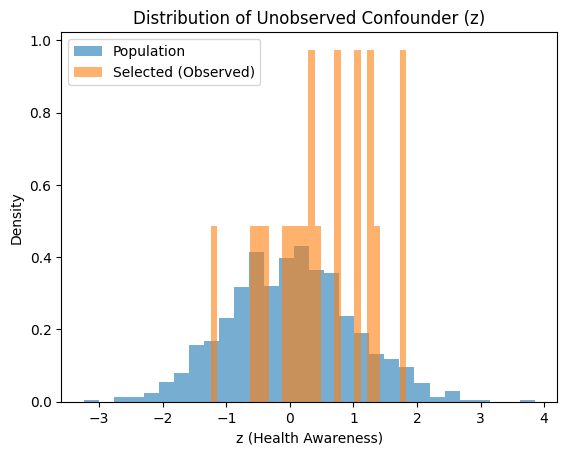

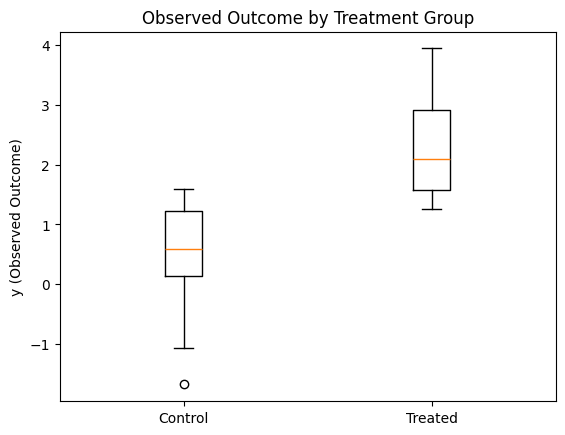

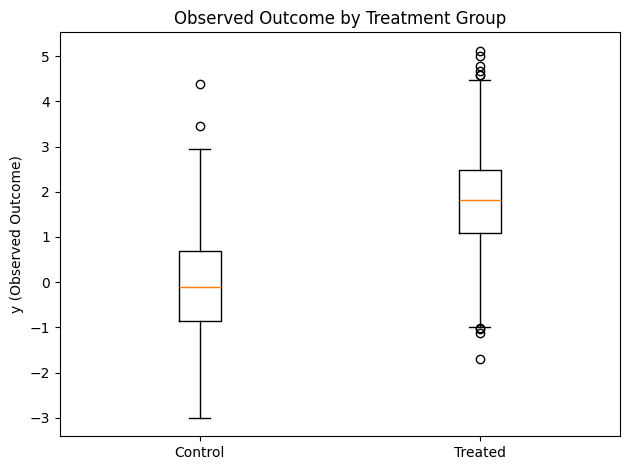

In [38]:
# Plot 1: Population vs Observed Distribution of Unobserved Confounder
fig1, ax1 = plt.subplots()
ax1.hist(pop["unobserved_confounder"], bins=30, alpha=0.6, label="Population", density=True)
ax1.hist(obs["unobserved_confounder"], bins=30, alpha=0.6, label="Selected (Observed)", density=True)
ax1.set_title("Distribution of Unobserved Confounder (z)")
ax1.set_xlabel("z (Health Awareness)")
ax1.set_ylabel("Density")
ax1.legend()

# Plot 2: Treatment vs Outcome in Observed Data
fig2, ax2 = plt.subplots()
ax2.boxplot([obs[obs["treatment_obs"] == 0]["y_obs"], obs[obs["treatment_obs"] == 1]["y_obs"]],
            tick_labels=["Control", "Treated"])
ax2.set_title("Observed Outcome by Treatment Group")
ax2.set_ylabel("y (Observed Outcome)")

# Plot 2: Treatment vs Outcome in Population Data
fig2, ax2 = plt.subplots()
ax2.boxplot([pop[pop["treatment_obs"] == 0]["y_obs"], pop[pop["treatment_obs"] == 1]["y_obs"]],
            tick_labels=["Control", "Treated"])
ax2.set_title("Observed Outcome by Treatment Group")
ax2.set_ylabel("y (Observed Outcome)")

# Show both plots
plt.tight_layout()
plt.show()

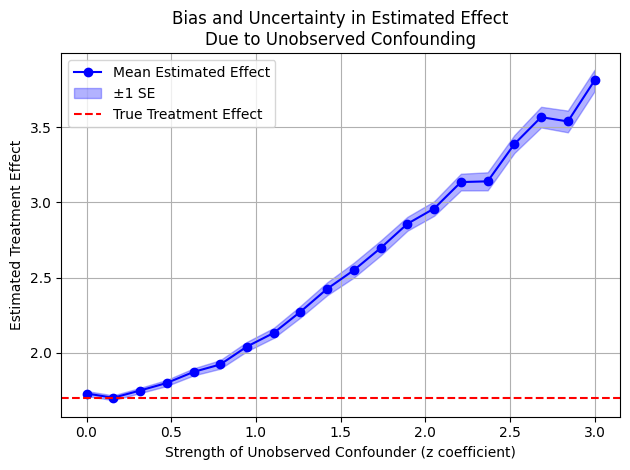

In [39]:
np.random.seed(42)
# Simulate multiple trials for each confounder strength to compute mean and standard error
n_trials = 100
confounder_strengths = np.linspace(0, 3.0, 20)
true_effect = 1.7
mean_effects = []
stderr_effects = []

# Function to compute naive treatment effect in observed data
def estimate_treatment_effect(obs_df):
    treated_mean = obs_df[obs_df["treatment_obs"] == 1]["y_obs"].mean()
    control_mean = obs_df[obs_df["treatment_obs"] == 0]["y_obs"].mean()
    return treated_mean - control_mean

def estimate_treatment_effect_ols(obs_df):
    X = obs_df[["treatment_obs"]] #, "observed_covariates"]]
    #X = sm.add_constant(X)
    y = obs_df["y_obs"]
    model = sm.OLS(y, X).fit()
    return model.params["treatment_obs"] #, model.bse["treatment_obs"]

for strength in confounder_strengths:
    estimates = []
    for _ in range(n_trials):
        obs_df, _ = clinical_trial_model(treatment_effect=true_effect, health_awareness=strength)
        est_effect = estimate_treatment_effect_ols(obs_df)
        estimates.append(est_effect)
    estimates = np.array(estimates)
    mean_effects.append(estimates.mean())
    stderr_effects.append(estimates.std(ddof=1) / np.sqrt(n_trials))

# Plot: Estimated Treatment Effect with Standard Error Bands
fig, ax = plt.subplots()
ax.plot(confounder_strengths, mean_effects, label="Mean Estimated Effect", color="blue", marker='o')
ax.fill_between(confounder_strengths,
                np.array(mean_effects) - np.array(stderr_effects),
                np.array(mean_effects) + np.array(stderr_effects),
                color="blue", alpha=0.3, label="±1 SE")
ax.axhline(true_effect, color='red', linestyle='--', label="True Treatment Effect")
ax.set_xlabel("Strength of Unobserved Confounder (z coefficient)")
ax.set_ylabel("Estimated Treatment Effect")
ax.set_title("Bias and Uncertainty in Estimated Effect\nDue to Unobserved Confounding")
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
prior_range = [0., 3.]
def generative_model(batch_size, health_awareness=None):
    param_batch = np.random.uniform(prior_range[0], prior_range[1], size=(batch_size, len(param_names)))
    if not health_awareness is None:  # we overwrite the samples
        param_batch[:, 1] = health_awareness

    # Initialize data array
    data = np.zeros((len(param_batch), n_samples, 2))
    dfs = []
    for i_p, param in enumerate(param_batch):
        # Generate data for the clinical model with the given parameter
        # Unpack the parameters
        treatment_effect, _health_awareness = param

        data_i, _ = clinical_trial_model(treatment_effect, health_awareness=_health_awareness)
        data[i_p] = data_i[['y_obs', 'treatment_obs']].values
        dfs.append(data_i)
    return {'sim_data': data, 'prior_draws': param_batch, 'obs_df': dfs}

In [41]:
np.random.seed(42)
valid_data = generative_model(100)

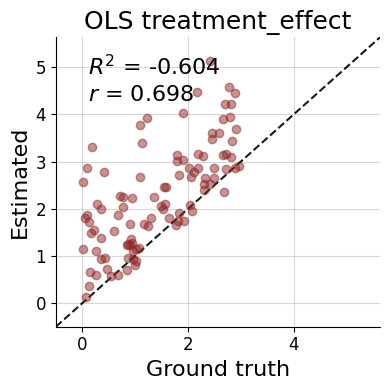

In [43]:
estimates_OLS = []
for obs_df in valid_data['obs_df']:
    est_effect = estimate_treatment_effect_ols(obs_df)
    estimates_OLS.append(est_effect)
estimates_OLS = np.array(estimates_OLS).reshape(len(valid_data['obs_df']), 1, 1)

bf.diagnostics.plot_recovery(estimates_OLS, valid_data['prior_draws'][:, :1], param_names=['OLS ' + p for p in param_names[:1]]);

In [44]:
# # ------------ MAXIMUM LIKELIHOOD ESTIMATION ------------
#
# def negative_log_likelihood(params, treatment, y_obs):
#     """
#     Calculate the negative log likelihood for the observed data
#
#     params[0]: theta
#     params[1]: sigma (standard deviation of z)
#     """
#     theta, sigma = params
#
#     n_obs = len(y_obs)
#     ll = 0
#
#     for i in range(n_obs):
#         t_i = treatment[i]
#         y_i = y_obs[i]
#
#         # Define the integrand function: f(z) = p(selection|z) * p(y|z,t) * p(z)
#         def integrand(z):
#             # Selection probability
#             p_selection = selection_probability(z)
#
#             # Likelihood of y given z and t: p(y|z,t) ~ N(θ·t + z, 0.5²)
#             p_y_given_z_t = stats.norm.pdf(y_i, loc=theta*t_i + z, scale=0.5)
#
#             # Prior on z: p(z) ~ N(0, σ²)
#             p_z = stats.norm.pdf(z, loc=0, scale=sigma)
#
#             return p_selection * p_y_given_z_t * p_z
#
#         # Integrate over z (numerically)
#         # We integrate over a reasonable range: ±5σ should cover most of the mass
#         z_range = 5 * sigma
#         integral_result, _ = quad(integrand, -z_range, z_range)
#
#         # Add log probability to the log likelihood
#         ll += np.log(max(integral_result, 1e-10))  # Avoid log(0)
#
#     return -ll  # Return negative log likelihood for minimization
#
# def fit_mle(obs_df):
#     """Fit the model using MLE"""
#     treatment = obs_df['treatment_obs'].values
#     y_obs = obs_df['y_obs'].values
#
#     # Initial parameter guess [theta, sigma]
#     initial_params = [0.0, 1.0]
#
#     # Bounds for parameters (theta can be any real number, sigma must be positive)
#     bounds = [(None, None), (0.01, None)]
#
#     # Minimize negative log likelihood
#     result = minimize(
#         negative_log_likelihood,
#         initial_params,
#         args=(treatment, y_obs),
#         bounds=bounds,
#         method='L-BFGS-B'
#     )
#
#     theta_mle, sigma_mle = result.x
#
#     return {
#         'theta': theta_mle,
#         'sigma': sigma_mle,
#         'convergence': result.success,
#         'log_likelihood': -result.fun
#     }
#
#
# prior_draws = np.random.uniform(0, 3, 100)
# estimates = []
#
# for true_effect in tqdm(prior_draws):
#     obs_df, _ = clinical_trial_model(treatment_effect=true_effect, health_awareness=np.random.uniform(0, 3))
#     mle_results = fit_mle(obs_df)
#     estimates.append(mle_results['theta'])
# estimates = np.array(estimates).reshape(-1, 1, 1)
#
# bf.diagnostics.plot_recovery(estimates, prior_draws.reshape(-1, 1), param_names=['MLE treatment_effect']);

DEBUG:cmdstanpy:found newer exe file, not recompiling
  0%|          | 0/100 [00:00<?, ?it/s]DEBUG:cmdstanpy:cmd: /Users/jonas.arruda/PyCharm Projects/SamplingBias/stan_model info
cwd: None
DEBUG:cmdstanpy:input tempfile: /var/folders/6l/dj45z5dn7zn0djmp1vjb65bh0000gn/T/tmpvzbqkjt_/vfnnov0p.json
13:44:37 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:idx 2
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/Users/jonas.arruda/PyCharm Projects/SamplingBias/stan_model', 'id=1', 'random', 'seed=71969', 'data', 'file=/var/folders/6l/dj45z5dn7zn0djmp1vjb65bh0000gn/T/tmpvzbqkjt_/vfnnov0p.json', 'output', 'file=/var/folders/6l/dj45z5dn7zn0djmp1vjb65bh0000gn/T/tmpvzbqkjt_/stan_modeltjwd9yts/stan_model-20250513134437_1.csv', 'method=sample', 'algorithm=hmc', 'adapt', 'engage

CPU times: user 4.63 s, sys: 6.43 s, total: 11.1 s
Wall time: 25.6 s


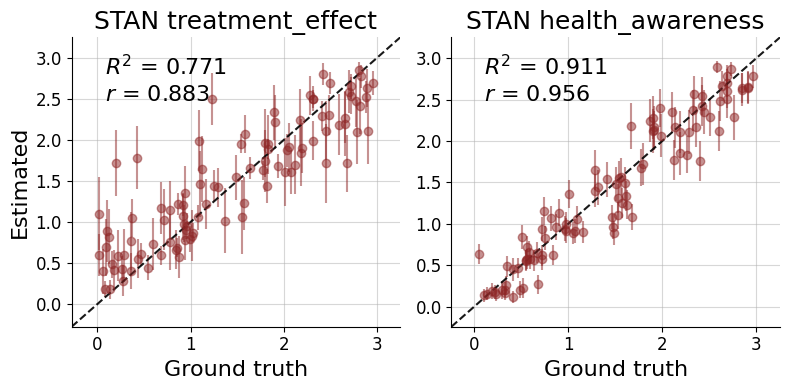

In [51]:
%%time

stan_model = CmdStanModel(stan_file='stan_model.stan')
def get_stan_posterior(obs_df, chains=4):

    # Prepare data for Stan
    stan_data = {
        'N': obs_df.shape[0],
        'T': obs_df['treatment_obs'].values,
        'Y': obs_df['y_obs'].values,
    }

    # Fit the model to the data
    fit = stan_model.sample(data=stan_data, show_progress=False, chains=chains)

    if len(param_names) == 1:
        return np.array(fit.draws_pd("theta"))
    return np.concatenate((fit.draws_pd("theta"), fit.draws_pd("sigma")), axis=-1)

estimates_STAN = []
for obs_df in tqdm(valid_data['obs_df']):
    est_effect = get_stan_posterior(obs_df)
    estimates_STAN.append(est_effect)
estimates_STAN = np.array(estimates_STAN).reshape(len(valid_data['obs_df']), -1, len(param_names))

bf.diagnostics.plot_recovery(estimates_STAN, valid_data['prior_draws'], param_names=['STAN ' + p for p in param_names])
bf.diagnostics.plot_sbc_ecdf(estimates_STAN, valid_data['prior_draws'], difference=True, param_names=['STAN ' + p for p in param_names]);

# Use BayesFlow

In [56]:
summary_net = DeepSet()

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=6,
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [57]:
def configurator(forward_dict: dict) -> dict:
    # Extract data
    x_data = forward_dict["sim_data"]
    #x_data[:, :, 0] = (x_data[:, :, 0] - _x_mean[0]) / _x_std[0]  # the other axis is binary
    out_dict = {
        'summary_conditions': x_data.astype(np.float32)
    }

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        #params = (params - _prior_mean) / _prior_std
        params = logit((params - prior_range[0]) / prior_range[1])
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

def configurator_inverse(forward_dict) -> dict:
    if isinstance(forward_dict, np.ndarray):
        return expit(forward_dict) * prior_range[1] + prior_range[0]
    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        #params = (params - _prior_mean) / _prior_std
        forward_dict["parameters"] = expit(params) * prior_range[1] + prior_range[0]
    return forward_dict

In [58]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    checkpoint_path=f'amortizer_unobserved_{len(param_names)}'
)

INFO:root:Initialized empty loss history.
INFO:root:Initialized networks from scratch.
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [59]:
if trainer.checkpoint_path is None or not os.path.exists(trainer.checkpoint_path):
    history = trainer.train_online(
        #simulations_dict=offline_data,
        epochs=10,
        batch_size=128,
        iterations_per_epoch=100,
        #early_stopping=True,
        validation_sims=valid_data
    )
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

Training epoch 1:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 1, Loss: 3.129


Training epoch 2:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 2, Loss: 2.910


Training epoch 3:   0%|          | 0/100 [00:00<?, ?it/s]

...

INFO:root:Validation, Epoch: 8, Loss: 2.209


Training epoch 9:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 9, Loss: 2.169


Training epoch 10:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 10, Loss: 2.164


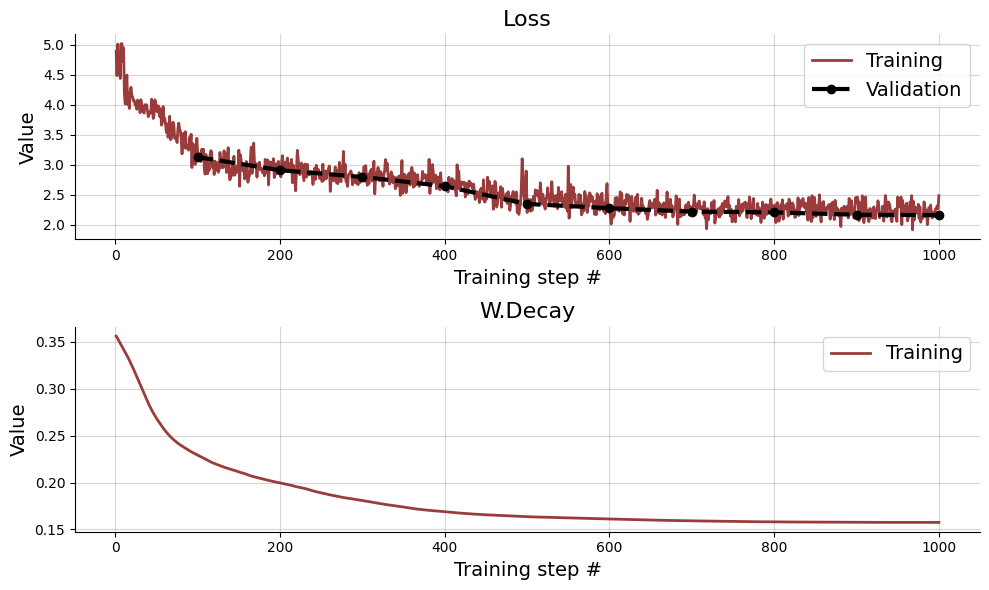

In [60]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [61]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=200)
posterior_samples = configurator_inverse(posterior_samples)

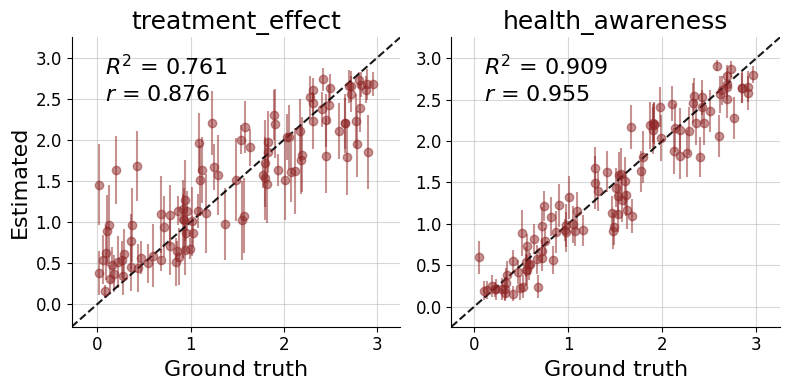

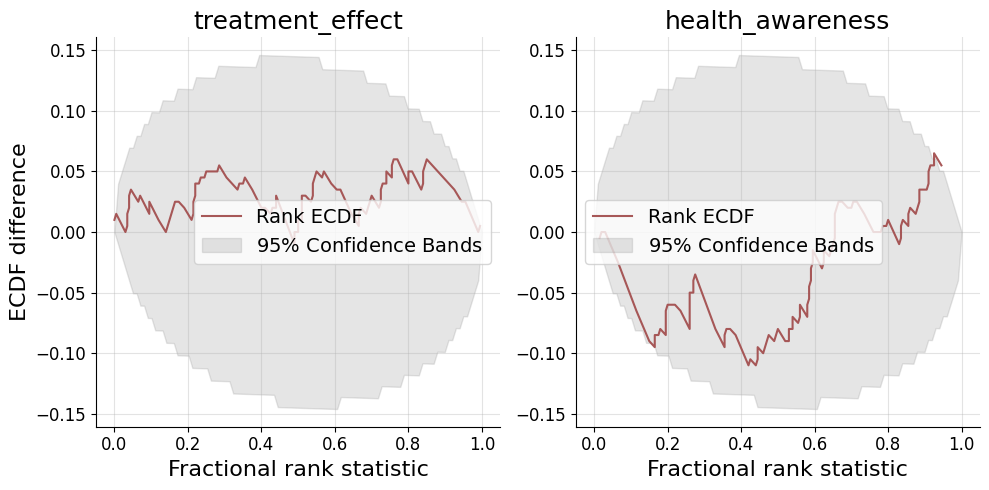

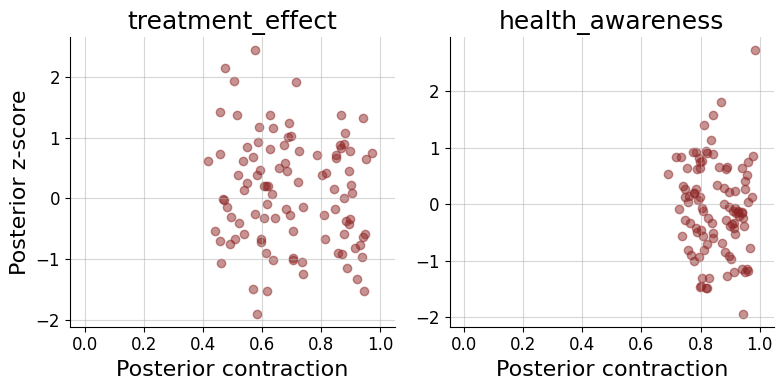

In [62]:
bf.diagnostics.plot_recovery(posterior_samples, valid_data['prior_draws'], param_names=param_names)
bf.diagnostics.plot_sbc_ecdf(posterior_samples, valid_data['prior_draws'], difference=True, param_names=param_names)
bf.diagnostics.plot_z_score_contraction(posterior_samples, valid_data['prior_draws'], param_names=param_names);

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/bayesflow/diagnostics.py:318: RuntimeWarning: divide by zero encountered in divide
  post_cont = 1 - (post_vars / prior_vars)


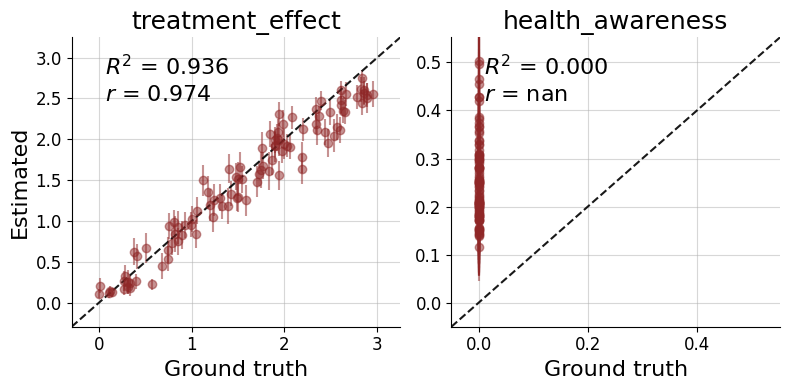

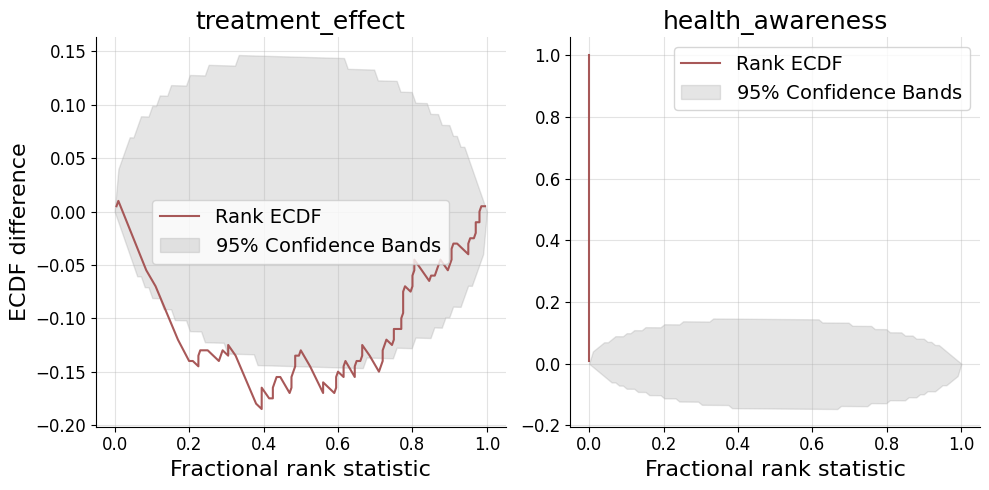

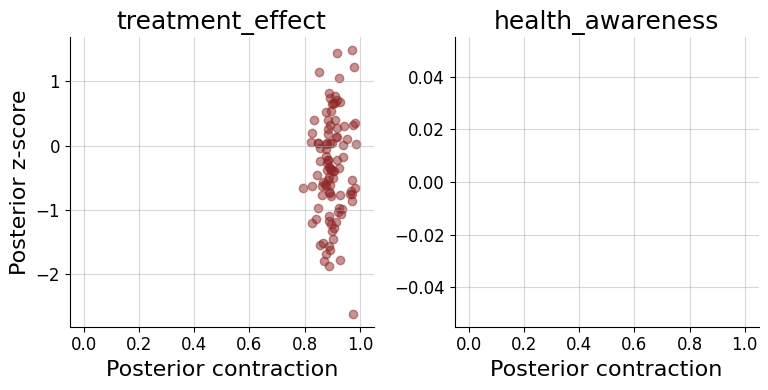

In [68]:
test_data = generative_model(100, health_awareness=0.)
posterior_samples = trainer.amortizer.sample(trainer.configurator(test_data), n_samples=200)
posterior_samples = configurator_inverse(posterior_samples)

bf.diagnostics.plot_recovery(posterior_samples, test_data['prior_draws'], param_names=param_names)
bf.diagnostics.plot_sbc_ecdf(posterior_samples, test_data['prior_draws'], difference=True, param_names=param_names)
bf.diagnostics.plot_z_score_contraction(posterior_samples, test_data['prior_draws'], param_names=param_names);